# QAOA：功能电路、论文时间预算与原文对照

本 Notebook 按论文 v1 式 (6) 字面构建迭代，保留开头的初始 H，不在 O_0 前后添加全寄存器 H。代码包含全部理想功能函数，资源时间另用式 (7)–(11) 估算。

**已标出原文内部约定问题、功能等价简化和未实现的容错部分。** 各节的引用注明印刷页码，完整对照在末尾。理想电路的 PASS 不表示容错编译或成功率定理已经复现。

修改图下正文后先保存 Notebook，再运行导出格；导出将直接使用这份正文，避免两份文字不同步。重新运行文件写入 results/，不会自动覆盖手工阅读笔记。


## 1. 环境与输出目录

先选择安装了 Qiskit 和绘图依赖的 Python 3 内核。若出现模块缺失，可运行下一格中的安装命令（默认注释）。`%pip` 会为当前内核安装依赖。

In [1]:
# 如需安装依赖，取消下面一行的注释后运行，再重新启动内核。
# %pip install "qiskit==2.5.2" "matplotlib==3.11.2" "pylatexenc>=2.10" "numpy>=2" ipykernel

In [2]:
from pathlib import Path
from types import SimpleNamespace
from copy import deepcopy
import csv, json, math, numbers
import numpy as np
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from IPython.display import display, Markdown, Math
from IPython import get_ipython
from IPython.core.pylabtools import select_figure_formats
select_figure_formats(get_ipython(), {'png'})
from qiskit import QuantumCircuit, QuantumRegister, qpy
from qiskit.circuit import Gate, Parameter, ParameterExpression
from qiskit.circuit.library import PhaseGate
from qiskit.quantum_info import Statevector, Operator
import qiskit

PAPER = "Omanakuttan et al., arXiv:2504.01897v1 (2025)"

def find_notebook_path():
    name = 'AA_QAOA_Qiskit.ipynb'
    for base in (Path.cwd(), *Path.cwd().parents):
        for candidate in (base/name, base/'notebooks'/name,
                          base/'circuit with corresponding time estimation/notebooks'/name,
                          base/'output/organized_code/circuit with corresponding time estimation/notebooks'/name):
            if candidate.is_file():
                return candidate.resolve()
    raise FileNotFoundError('请保存 Notebook，并从其目录或项目根目录运行。')

NOTEBOOK_PATH = find_notebook_path()
if NOTEBOOK_PATH.parent.name == 'notebooks':
    OUTPUT_DIR = NOTEBOOK_PATH.parent.parent / 'results'
else:
    OUTPUT_DIR = NOTEBOOK_PATH.parent / 'notebook_outputs'
ASSET_DIR = OUTPUT_DIR / 'obsidian_assets'
DATA_DIR = OUTPUT_DIR / 'data'
ASSET_DIR.mkdir(parents=True, exist_ok=True)
DATA_DIR.mkdir(parents=True, exist_ok=True)
print(f'Qiskit {qiskit.__version__}; Matplotlib {matplotlib.__version__}')
print('生成文件:', OUTPUT_DIR.name)


Qiskit 2.5.2; Matplotlib 3.11.2
生成文件: results


## 2. 计算一条子句的 OR 标记

`clause` 使用 `(数据位下标, 是否为正文字)` 表示一条子句，例如 `(1, False)` 表示 $\neg x_1$。

所有文字均为假时子句违约。先对正文字变量施加 $X$，将违约模式映射为全 $1$ 控制条件，用 MCX 计算 UNSAT，再用 $X$ 转成 SAT：

$$C_j(x)=1-\prod_a(1-\ell_{ja}(x)).$$

在辅助位初态 $|0\rangle$ 上，最终写入 $C_j(x)$。整个子电路可取逆，辅助位能在使用后清零。
重复相同文字会去重，含 x 与非 x 的子句恒真，空 OR 恒假。它们均按布尔意义处理，不能把重复的控制位直接交给 MCX。变量 i 对应整数赋值的第 i 位。


In [3]:
def _positive_integer(value, name):
    if isinstance(value, (bool, np.bool_)) or not isinstance(value, numbers.Integral) or value < 1:
        raise ValueError(f'{name} must be a positive integer.')
    return int(value)

def _validate_angle(angle, name):
    if isinstance(angle, ParameterExpression):
        return angle
    if isinstance(angle, (bool, np.bool_)) or not isinstance(angle, numbers.Real) or not math.isfinite(angle):
        raise ValueError(f'{name} must be a finite real angle or a Qiskit parameter.')
    return float(angle)

def _normalize_clause(n, clause):
    """Deduplicate literals; None means a tautology, [] means constant false.

    The paper samples variables with replacement (Sec. IV.F). Repeated controls
    cannot be passed directly to MCX, but OR semantics can be normalized exactly.
    """
    _positive_integer(n, 'n')
    literals = {}
    tautology = False
    for literal in clause:
        if not isinstance(literal, (tuple, list)) or len(literal) != 2:
            raise ValueError('Each literal must be (variable_index, positive_bool).')
        index, positive = literal
        if isinstance(index, (bool, np.bool_)) or not isinstance(index, numbers.Integral) or not 0 <= index < n:
            raise ValueError(f'Variable index must be an integer in [0, {n}).')
        if not isinstance(positive, (bool, np.bool_)):
            raise ValueError('Literal sign must be True or False.')
        index, positive = int(index), bool(positive)
        if index in literals and literals[index] != positive:
            tautology = True
        literals[index] = positive
    return None if tautology else list(literals.items())

def clause_compute(n, clause):
    """Reversibly XOR the OR of literals into flag n; never repeat controls."""
    literals = _normalize_clause(n, clause)
    qc = QuantumCircuit(n + 1, name='OR_clause')
    if literals is None:
        qc.x(n)  # A clause containing x and NOT x is always true.
        return qc
    if not literals:
        return qc  # An empty OR is false.
    positive = [i for i, sign in literals if sign]
    if positive:
        qc.x(positive)
    qc.mcx([i for i, _ in literals], n)
    if positive:
        qc.x(positive)
    qc.x(n)  # Complement UNSAT to obtain SAT.
    return qc

def evaluate(n, clause, x):
    """Classical OR evaluation; x_i is bit i (Qiskit little-endian convention)."""
    _normalize_clause(n, clause)  # Validate, while evaluating the original OR.
    if isinstance(x, (bool, np.bool_)) or not isinstance(x, numbers.Integral) or not 0 <= x < 2**n:
        raise ValueError('Assignment x must be an integer in [0, 2**n).')
    return int(any(((x >> i) & 1) if sign else 1 - ((x >> i) & 1) for i, sign in clause))


## 3. Phaser

公式 (4) 定义 $H_C=-\sum_j\sum_x C_j(x)|x\rangle\langle x|$，因此

$$e^{-i\gamma H_C}|x\rangle=e^{i\gamma\sum_j C_j(x)}|x\rangle.$$

对每条子句计算 $C_j$，在标记位施加 $P(+\gamma)$，随后反计算。正号来自 Hamiltonian 前的负号。

下面的 MCX 电路实现精确可逆功能，论文公式 (9) 的时间由另外的 TACU 并行编译给出。
> **[原文内部约定问题，p.4 与 p.10]** 式 (4) 的负号与式 (3) 推出正相位 $e^{+i\gamma C_j(x)}$，式 (20) 印刷为负相位 $e^{-i\gamma C_j(x)}$。本实现明确选式 (3)–(4) 的约定，即 `p(+gamma)`。

> **[功能等价简化]** 用 SAT 标记而非唯一 UNSAT 模式实现子句相位。等价关系是 $e^{i\gamma C_j}=e^{i\gamma}e^{-i\gamma(1-C_j)}$；对控制文字的 X 位置、相位号和全局相位必须一起核对，不能只比较两张图的 X 门位置。


In [4]:
def phaser(n, clauses, gamma):
    """Eqs. (3)-(4): positive phase on satisfied clauses; ideal MCX circuit.

    Eq. (20) prints the opposite sign. We explicitly follow H_C in Eq. (4).
    """
    _positive_integer(n, 'n')
    gamma = _validate_angle(gamma, 'gamma')
    qc = QuantumCircuit(n + 1, name='phaser')
    for clause in clauses:
        compute = clause_compute(n, clause)
        qc.compose(compute, inplace=True)
        qc.p(gamma, n)
        qc.compose(compute.inverse(), inplace=True)
    return qc


## 4. Mixer

$$H_M=\frac12\sum_j X_j,\qquad e^{-i\beta H_M}=\bigotimes_j R_x(\beta).$$

由于 $R_x(\theta)=e^{-i\theta X/2}$，这里使用 `rx(beta)`。所有数据位的旋转并行，论文时间为 $T_{\mathrm{mixer}}=n_PT_{\mathrm{LC}}$。

In [5]:
def mixer(n, beta):
    """H_M = (1/2) sum X_i implies Rx(beta), with exact ideal rotations."""
    n = _positive_integer(n, 'n')
    beta = _validate_angle(beta, 'beta')
    qc = QuantumCircuit(n, name='mixer')
    qc.rx(beta, range(n))
    return qc


## 5. 两个 Oracle

SAT oracle 检查整份公式：

$$O_C|x\rangle=(-1)^{\bigwedge_j C_j(x)}|x\rangle.$$

先计算各条 OR 标记，给全 $1$ 标记模式施加 $\pi$ 相位，随后清零标记位。

全零态 oracle 为

$$O_0=I-2|0^n\rangle\langle0^n|.$$

先 $X^{\otimes n}$，目标位上的 $H\to\mathrm{MCX}\to H$ 实现受控 $Z$，再 $X^{\otimes n}$。
**[功能等价简化]** 两个 Oracle 都是理想可逆实现，未实现论文附录的 TACU/测量反馈与空间调度。O_0 内部的两个目标位 H 是受控 Z 分解；它们不是已移除的全寄存器 H 层。


In [6]:
def sat_oracle(n, clauses):
    """Flag all clauses, apply phase pi on all-true flags, then uncompute.

    Functional simplification: this is not Appendix C's timed AND-tree schedule.
    A formula must contain at least one clause; individual empty ORs are allowed.
    """
    n = _positive_integer(n, 'n')
    clauses = list(clauses)
    m = len(clauses)
    if not m:
        raise ValueError('The SAT instance must contain at least one clause.')
    qc = QuantumCircuit(n + m, name='OC')
    for j, clause in enumerate(clauses):
        qc.compose(clause_compute(n, clause), list(range(n)) + [n + j], inplace=True)
    phase = PhaseGate(math.pi)
    qc.append(phase if m == 1 else phase.control(m - 1), list(range(n, n + m)))
    for j in reversed(range(m)):
        qc.compose(clause_compute(n, clauses[j]).inverse(), list(range(n)) + [n + j], inplace=True)
    return qc

def zero_oracle(n):
    """I - 2|0^n><0^n|, including n=1 without an invalid zero-control MCX."""
    n = _positive_integer(n, 'n')
    qc = QuantumCircuit(n, name='O0')
    if n == 1:
        qc.global_phase = math.pi
        qc.z(0)  # -Z = diag(-1, +1).
        return qc
    qc.x(range(n))
    # These TWO target-wire H gates implement controlled-Z; they are not the
    # removed full-register basis conversion layers around O0.
    qc.h(n - 1)
    qc.mcx(list(range(n - 1)), n - 1)
    qc.h(n - 1)
    qc.x(range(n))
    return qc


## 6. 正向与逆向 QAOA

正向每层按 phaser → mixer 执行；逆向用 `.inverse()`，既倒序也对门取逆。

$$U_l=e^{-i\beta_lH_M}e^{-i\gamma_lH_C},\qquad U_l^\dagger=e^{+i\gamma_lH_C}e^{+i\beta_lH_M}.$$

参数数组一一对应 QAOA 层，不包含训练步骤。
`betas` 与 `gammas` 必须长度相同；不匹配立即报错，不再由 zip 静默丢层。零层允许用于数学边界检查；资源预算要求 p>=1。


In [7]:
def qaoa(n, clauses, betas, gammas):
    """QAOA evolution U; initial H preparation is excluded, as in Eq. (3)."""
    n = _positive_integer(n, 'n')
    clauses, betas, gammas = list(clauses), list(betas), list(gammas)
    if not clauses:
        raise ValueError('The SAT instance must contain at least one clause.')
    for clause in clauses:
        _normalize_clause(n, clause)
    if len(betas) != len(gammas):
        raise ValueError('betas and gammas must have equal lengths; no layer may be silently dropped.')
    qc = QuantumCircuit(n + len(clauses), name='U_QAOA')
    for beta, gamma in zip(betas, gammas):
        qc.compose(phaser(n, clauses, gamma), list(range(n)) + [n], inplace=True)
        qc.compose(mixer(n, beta), range(n), inplace=True)
    return qc


## 7. 按论文式 (6) 构建迭代

初态制备只在开头执行一次：

$$|0^n\rangle\xrightarrow{H^{\otimes n}}|+\rangle^{\otimes n}\xrightarrow{U}|\psi\rangle.$$

这里 $U$ 是式 (3) 的 QAOA 演化，不含初始 H。每轮直接按式 (6) 从左到右执行：

$$O_C\longrightarrow U^\dagger\longrightarrow O_0\longrightarrow U,\qquad Q=UO_0U^\dagger O_C.$$

本版本保留初始 H，$O_0$ 前后没有全寄存器 H 层。经过 $O_C$ 标记后，$U^\dagger$ 一般不会将整个态还原为均匀叠加态；$O_0$ 只翻转当时的全零分量。

> **[原文内部约定问题，p.3–4]** 式 (2) 的初态与式 (6) 的零态反射定义并未显式匹配。当前代码忠实于式 (6) 字面顺序，未补 H，也不声称因此已证明标准 AA 的概率公式。详细解释见末尾原文对照第 1 项。

初始演化预算与每轮主体预算分别为

$$T_U=p(T_{\mathrm{phaser}}+T_{\mathrm{mixer}}),\qquad T_Q=2T_U+T_{O_C}+T_{O_0}.$$

图中四根线表示一般的数据寄存器，方框是不可直接模拟的压缩模块；实际演示另有清零辅助位。重复的是最后四个模块，初始 H 和第一次 U 不在重复段内。


In [8]:
def paper_iteration(n, clauses, betas, gammas):
    """Literal Eq. (6): U O0 U-dagger OC; no full-register H around O0.

    Following Eq. (6) literally does not resolve its preparation convention
    mismatch with Eqs. (2)-(3); this function claims no standard-AA probability law.
    """
    clauses = list(clauses)
    u = qaoa(n, clauses, betas, gammas)
    qc = sat_oracle(n, clauses)
    qc.name = 'Q_paper_Eq6'
    qc.compose(u.inverse(), inplace=True)
    qc.compose(zero_oracle(n), range(n), inplace=True)
    qc.compose(u, inplace=True)
    return qc

def qaoa_data_operator(n, clauses, betas, gammas):
    """Independent mathematical reference on data only, for small numeric cases."""
    n = _positive_integer(n, 'n')
    if len(betas) != len(gammas):
        raise ValueError('betas and gammas must have equal lengths.')
    size = 2**n
    counts = np.array([sum(evaluate(n, clause, x) for clause in clauses) for x in range(size)])
    matrix = np.eye(size, dtype=complex)
    for beta, gamma in zip(betas, gammas):
        beta, gamma = float(beta), float(gamma)
        rx = np.array([[math.cos(beta/2), -1j*math.sin(beta/2)],
                       [-1j*math.sin(beta/2), math.cos(beta/2)]])
        parallel_rx = np.array([[1.0 + 0j]])
        for _ in range(n):
            parallel_rx = np.kron(parallel_rx, rx)
        matrix = parallel_rx @ (np.exp(1j*gamma*counts)[:, None] * matrix)
    return matrix


## 8. 可运行的固定 8-SAT 演示

示例 n=8,m=2,p=2,R=1。初始 H 和 U 制备一次，随后运行整数 R 轮字面式 (6)，最后测量数据位。

**[与原文实例不同]** 两条子句和角度为固定演示值，未经训练；这不是密度 m/n=176 的随机阈值实例。小例子的成功率与后面的 n=191 资源模型分别计算。


In [9]:
N_DEMO = 8
CLAUSES_DEMO = [
    [(i, i != 1) for i in range(N_DEMO)],
    [(i, i % 2 == 0) for i in range(N_DEMO)],
]
BETAS_DEMO = [0.41, 0.72]
GAMMAS_DEMO = [0.32, -0.59]
R_DEMO = 1

u_demo = qaoa(N_DEMO, CLAUSES_DEMO, BETAS_DEMO, GAMMAS_DEMO)
q_demo = paper_iteration(N_DEMO, CLAUSES_DEMO, BETAS_DEMO, GAMMAS_DEMO)
prep_demo = QuantumCircuit(u_demo.num_qubits)
prep_demo.h(range(N_DEMO))
prep_demo.compose(u_demo, inplace=True)

run_demo = prep_demo.copy()
for _ in range(R_DEMO):
    run_demo.compose(q_demo, inplace=True)
from qiskit import ClassicalRegister
run_demo.add_register(ClassicalRegister(N_DEMO, 'readout'))
run_demo.measure(range(N_DEMO), range(N_DEMO))
run_demo.name = f'toy_8SAT_p{len(BETAS_DEMO)}_R{R_DEMO}_paper_Eq6'

with (OUTPUT_DIR / 'executable_8SAT_example.qpy').open('wb') as stream:
    qpy.dump(run_demo, stream)
print("可运行电路:", run_demo.name, run_demo.num_qubits, "量子位;", run_demo.num_clbits, "经典位")

可运行电路: toy_8SAT_p2_R1_paper_Eq6 10 量子位; 8 经典位


### 小例子成功率与独立数学参考

状态向量与独立的数据寄存器矩阵计算分别演化整数轮数，并比较结果和辅助位清零。字面式 (6) 不被预设满足标准 AA 的概率规律；成功率下降也不直接解释为标准 AA overshoot。


In [10]:
psi_demo = Statevector.from_instruction(prep_demo)
amplified_demo = psi_demo
for _ in range(R_DEMO):
    amplified_demo = amplified_demo.evolve(q_demo)

good_demo = [x for x in range(2**N_DEMO)
             if all(evaluate(N_DEMO, clause, x) for clause in CLAUSES_DEMO)]
p_before_demo = float(sum(abs(psi_demo.data[x])**2 for x in good_demo))
p_after_demo = float(sum(abs(amplified_demo.data[x])**2 for x in good_demo))
# Independently apply the paper operator on the clean data subspace.
u_data_demo = qaoa_data_operator(N_DEMO, CLAUSES_DEMO, BETAS_DEMO, GAMMAS_DEMO)

o0_demo = np.ones(2**N_DEMO); o0_demo[0] = -1
oc_demo = np.ones(2**N_DEMO); oc_demo[good_demo] = -1
expected_demo = psi_demo.data[:2**N_DEMO].copy()
for _ in range(R_DEMO):
    expected_demo = u_data_demo @ (o0_demo * (u_data_demo.conj().T @ (oc_demo * expected_demo)))
p_expected_demo = float(sum(abs(expected_demo[x])**2 for x in good_demo))
assert np.max(np.abs(amplified_demo.data[:2**N_DEMO] - expected_demo)) < 1e-10
assert np.linalg.norm(amplified_demo.data[2**N_DEMO:]) < 1e-10

display(Math(fr"P_0={p_before_demo:.8f},\qquad P_{{{R_DEMO}}}={p_after_demo:.8f},\qquad P_{{\mathrm{{operator}}}}={p_expected_demo:.8f}"))


<IPython.core.display.Math object>

### 完整理想功能检查

检查 256 个 8-SAT 子句输入、重复文字/恒真/空 OR、相位正负号、1–3 比特 O_0、单子句 O_C、逆电路、独立数学 U 与 Q、三轮复数态演化、辅助位清零和错误输入拒绝。PASS 只覆盖理想功能，不覆盖容错调度或标准 AA 成功率定理。


In [11]:
def verify():
    """Check independent ideal-unitary semantics and actual input failure cases."""
    n = 3
    clauses = [[(0, True), (1, False)], [(1, True), (2, True)]]
    beta, gamma = .613, .371
    error = 0.0
    for x in range(2**n):
        actual = Statevector.from_int(x, 2**(n+1)).evolve(phaser(n, clauses, gamma)).data
        expected = np.zeros_like(actual)
        expected[x] = np.exp(1j*gamma*sum(evaluate(n, c, x) for c in clauses))
        error = max(error, float(np.max(np.abs(actual-expected))))
        actual = Statevector.from_int(x, 2**(n+len(clauses))).evolve(sat_oracle(n, clauses)).data
        expected = np.zeros_like(actual)
        expected[x] = (-1)**int(all(evaluate(n, c, x) for c in clauses))
        error = max(error, float(np.max(np.abs(actual-expected))))
    assert error < 1e-10
    for size in (1, 2, 3):
        assert np.allclose(Operator(zero_oracle(size)).data, np.diag([-1]+[1]*(2**size-1)))
    assert np.allclose(Operator(mixer(1, beta)).data,
                       [[math.cos(beta/2), -1j*math.sin(beta/2)],
                        [-1j*math.sin(beta/2), math.cos(beta/2)]])
    betas, gammas = [.41, .72], [.32, -.59]
    u = qaoa(n, clauses, betas, gammas)
    u_full = Operator(u).data
    reference_u = qaoa_data_operator(n, clauses, betas, gammas)
    size = 2**n
    u_error = float(np.max(np.abs(u_full[:size, :size]-reference_u)))
    assert u_error < 1e-10 and np.max(np.abs(u_full[size:, :size])) < 1e-10
    inverse_error = float(np.max(np.abs(Operator(u.inverse()).data @ u_full - np.eye(2**u.num_qubits))))
    assert inverse_error < 1e-10
    good = [x for x in range(size) if all(evaluate(n, c, x) for c in clauses)]
    o0 = np.diag([-1]+[1]*(size-1))
    oc = np.diag([-1 if x in good else 1 for x in range(size)])
    reference_q = reference_u @ o0 @ reference_u.conj().T @ oc
    q = paper_iteration(n, clauses, betas, gammas)
    q_full = Operator(q).data
    q_error = float(np.max(np.abs(q_full[:size, :size]-reference_q)))
    assert q_error < 1e-10 and np.max(np.abs(q_full[size:, :size])) < 1e-10
    assert q.count_ops().get('h', 0) == 2  # Only target-wire O0 decomposition.
    prep = QuantumCircuit(u.num_qubits)
    prep.h(range(n)); prep.compose(u, inplace=True)
    state = Statevector.from_instruction(prep)
    p_before = float(sum(abs(state.data[x])**2 for x in good))
    result = state.evolve(q)
    p_after = float(sum(abs(result.data[x])**2 for x in good))
    # Complex arbitrary input, several rounds, and ancilla cleanup.
    rng = np.random.default_rng(20261009)
    vector = rng.normal(size=size) + 1j*rng.normal(size=size)
    vector /= np.linalg.norm(vector)
    extended = np.zeros(2**u.num_qubits, dtype=complex); extended[:size] = vector
    actual, expected = Statevector(extended), vector
    for _ in range(3):
        actual, expected = actual.evolve(q), reference_q @ expected
        assert np.max(np.abs(actual.data[:size]-expected)) < 1e-10
        assert np.linalg.norm(actual.data[size:]) < 1e-10
    # Literal repetition, tautology, empty OR, and one-literal clauses.
    edge_clauses = [[(0, True), (0, True)], [(1, True), (1, False)], [], [(2, False)]]
    for clause in edge_clauses:
        gate = clause_compute(n, clause)
        for x in range(size):
            for flag in (0, 1):
                actual = Statevector.from_int(x + flag*size, 2**(n+1)).evolve(gate).data
                expected_index = x + size*(flag ^ evaluate(n, clause, x))
                assert abs(actual[expected_index]-1) < 1e-10
    for x in range(2):
        actual = Statevector.from_int(x, 4).evolve(sat_oracle(1, [[(0, True)]])).data
        assert abs(actual[x]-(-1)**x) < 1e-10 and np.linalg.norm(actual[2:]) < 1e-10
    invalid = [lambda: qaoa(n, clauses, [1, 2], [1]),
               lambda: zero_oracle(0), lambda: zero_oracle(1.5),
               lambda: mixer(1, float('nan')),
               lambda: clause_compute(2, [(2, True)]),
               lambda: sat_oracle(2, [])]
    for call in invalid:
        try:
            call()
        except ValueError:
            continue
        raise AssertionError('Invalid input was accepted.')
    c8 = [(i, i != 1) for i in range(8)]
    for x in range(256):
        actual = Statevector.from_int(x, 512).evolve(clause_compute(8, c8)).data
        assert abs(actual[x + 256*evaluate(8, c8, x)]-1) < 1e-10
    return dict(status='PASS', qiskit_version=qiskit.__version__,
                maximum_truth_table_error=error, qaoa_reference_error=u_error,
                iteration_reference_error=q_error, inverse_error=inverse_error,
                p_before=p_before, p_after=p_after,
                checked='256-input 8-SAT clause; repeated literals and constants; phase sign; O0 n=1,2,3; '
                        'single-clause OC; inverse; independent U and Eq.(6) matrices; three-round complex-state evolution; '
                        'clean ancillas; unequal-angle and invalid-input rejection.',
                scope='Ideal circuit semantics only; PASS does not validate FT compilation or standard-AA success scaling.')


In [12]:
verification = verify()
# 检查结果显示在单元格中，不另存诊断 JSON。
print(json.dumps(verification, ensure_ascii=False, indent=2))

{
  "status": "PASS",
  "qiskit_version": "2.5.2",
  "maximum_truth_table_error": 1.2246467991473532e-16,
  "qaoa_reference_error": 1.2412670766236366e-16,
  "iteration_reference_error": 3.887667216744191e-16,
  "inverse_error": 4.457685769774389e-16,
  "p_before": 0.6029093753453504,
  "p_after": 0.5481054836242167,
  "checked": "256-input 8-SAT clause; repeated literals and constants; phase sign; O0 n=1,2,3; single-clause OC; inverse; independent U and Eq.(6) matrices; three-round complex-state evolution; clean ancillas; unequal-angle and invalid-input rejection.",
  "scope": "Ideal circuit semantics only; PASS does not validate FT compilation or standard-AA success scaling."
}


## 9. 用论文公式估算运行时间

$$
\begin{aligned}
T_{\mathrm{LC}}&=d\times1\,\mu\mathrm{s},\\
T_{\mathrm{mixer}}&=n_P T_{\mathrm{LC}}, &&\text{(8)}\\
T_{\mathrm{phaser}}&=(c+n_P+4\lceil\log_2 k\rceil)T_{\mathrm{LC}}, &&\text{(9)}\\
T_{O_C}&=4c\log_2(km/c)T_{\mathrm{LC}}, &&\text{(10)}\\
T_{O_0}&=4\log_2 n\;T_{\mathrm{LC}}, &&\text{(11)}\\
T_U&=p(T_{\mathrm{mixer}}+T_{\mathrm{phaser}}),\\
T_Q&=2T_U+T_{O_C}+T_{O_0},\\
T_q&=\frac{\pi}{4\sqrt P}T_Q,\quad P=2^{-0.69p^{-0.32}n}. &&\text{(7)}
\end{aligned}
$$

默认 $c=2112$ 与 $n_P=27$ 为明示的演示选取，未声称复现论文的全部交叉点参数。$k=8$ 固定。公式 (10)–(11) 是正文近似，不是精确整数深度。
**[资源估算范围]** 这些数值来自论文预算，不来自本 Notebook 的理想门数或电路深度。c 和 nP 手动输入，未执行实际染色/相位合成。nP 表示完整相位门分解耗时，不是“一门一个周期”。模型 P、连续轮数、稳健协议预算均与小例子的状态向量成功率分开，不能据此为字面式 (6) 保证平方根加速。


In [13]:
def resource_estimate(a):
    """Eqs. (7)-(11) paper budget; independent of ideal circuit gate/depth counts."""
    n, p = _positive_integer(a.n, 'n'), _positive_integer(a.p, 'p')
    d, np_cycles = _positive_integer(a.d, 'd'), _positive_integer(a.np, 'nP')
    m = 176*n if a.m is None else _positive_integer(a.m, 'm')
    c = _positive_integer(a.c, 'c')
    if n < 8 or c > m:
        raise ValueError('This resource model requires n>=8 and 1<=c<=m (fixed k=8).')
    tlc = d * 1e-6
    counts = dict(mixer=np_cycles, phaser=c+np_cycles+4*math.ceil(math.log2(8)),
                  OC=4*c*math.log2(8*m/c), O0=4*math.log2(n))
    times = {key: value*tlc for key, value in counts.items()}
    tu = p*(times['mixer'] + times['phaser'])
    tround = 2*tu + times['OC'] + times['O0']
    log2_probability = -.69*p**(-.32)*n
    probability = 2**log2_probability
    try:
        rounds = math.pi/4 * 2**(-log2_probability/2)
    except OverflowError as error:
        raise ValueError('The modeled runtime exceeds floating-point range.') from error
    if probability == 0 or not math.isfinite(4*rounds*tround):
        raise ValueError('The modeled probability/runtime exceeds floating-point range.')
    return dict(source=PAPER, k=8, n=n, m=m, p=p, c=c, nP=np_cycles, d=d,
                TLC_seconds=tlc, component_logical_cycles=counts, component_seconds=times,
                T_U_seconds=tu, T_AA_round_seconds=tround, success_model=probability,
                R_eq7_continuous=rounds, T_eq7_seconds=rounds*tround,
                T_with_initial_U_seconds=tu+rounds*tround,
                T_robust_main_text_approx_seconds=4*rounds*tround,
                robust_delta=1/16, robust_factor=4,
                model_scope='Paper Eq.(7) budget, not a runtime or success guarantee for the simulated circuit.',
                implemented_ft_schedule=False, coloring_computed=False,
                assumptions={'c': 'Manually supplied color count; default 2112 is empirical 12r.',
                             'nP': 'Manually supplied phase-synthesis cycles; default 27 is illustrative, not Table III cubic NT=24.',
                             'TLC': 'd QEC rounds at the paper-assumed 1 microsecond per round.',
                             'success': 'Instance-average 8-SAT model from the cited study; not the toy circuit probability.'},
                note='Eqs.(10)-(11) are main-text approximations, not exact integer schedules. '
                     'TACU, phase synthesis, factories, routing, training, resets and readout are not simulated. '
                     'The robust factor is a paper protocol budget; the protocol is not implemented.')


In [14]:
# 修改这格参数即可重新计算；它们与上面的可运行小例子分开。
RESOURCE_INPUTS = dict(n=191, m=None, p=253, c=2112, np=27, d=29)
timing = resource_estimate(SimpleNamespace(**RESOURCE_INPUTS))
print("资源输入:", {key: timing[key] for key in ('n','m','k','p','c','nP','d')})
for component, seconds in timing['component_seconds'].items():
    display(Math(fr"T_{{\mathrm{{{component}}}}}={seconds:.9f}\,\mathrm{{s}}"))
display(Math(fr"T_U={timing['T_U_seconds']:.6f}\,\mathrm{{s}},\quad T_Q={timing['T_AA_round_seconds']:.6f}\,\mathrm{{s}}"))
display(Math(fr"R_{{\mathrm{{Eq7}}}}\simeq{timing['R_eq7_continuous']:.3f},\quad T_q\simeq{timing['T_eq7_seconds']/3600:.4f}\,\mathrm{{h}}"))
display(Math(fr"T_{{\mathrm{{with\ init}}}}\simeq{timing['T_with_initial_U_seconds']/3600:.4f}\,\mathrm{{h}},\quad T_{{\mathrm{{robust}}}}\simeq{timing['T_robust_main_text_approx_seconds']/3600:.4f}\,\mathrm{{h}}"))

资源输入: {'n': 191, 'm': 33616, 'k': 8, 'p': 253, 'c': 2112, 'nP': 27, 'd': 29}


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

## 10. 分段绘图与 Obsidian 图片导出

每张图对应一个代码格。图片不包含底部说明，解释与公式放在紧接图后的 Markdown 格中。

总览使用四根线压缩表示 $n$ 位寄存器；方框用于表达模块关系。实际可运行的门定义在前面的函数中。Phaser 调度图是资源示意。

In [15]:
def schematic_block(circuit, label, name='block'):
    circuit.append(Gate(name, circuit.num_qubits, [], label=label), range(circuit.num_qubits))

def draw_and_export(circuit, stem):
    # 让 Qiskit 决定图尺寸，避免长寄存器的标签比例失真。
    fig = circuit.draw(output='mpl', fold=-1, style={'fontsize':12, 'subfontsize':10})
    fig.savefig(ASSET_DIR / f'{stem}.png', dpi=180, bbox_inches='tight', facecolor='white')
    fig.savefig(ASSET_DIR / f'{stem}.svg', bbox_inches='tight', facecolor='white')
    display(fig)
    plt.close(fig)

### 图 1：初态制备与式 (6) 的一轮迭代


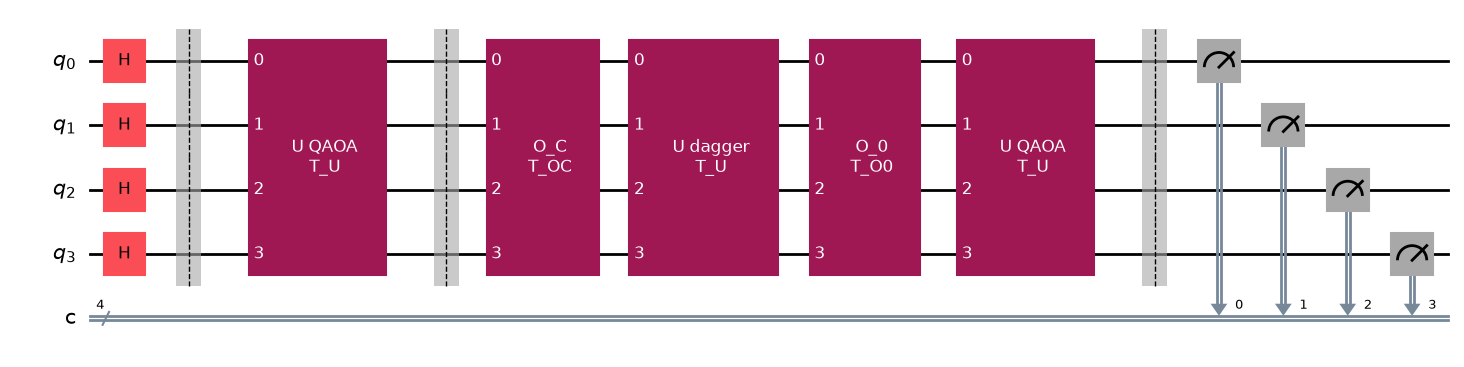

In [16]:
overview = QuantumCircuit(4, 4)
overview.h(range(4)); overview.barrier()
schematic_block(overview, 'U QAOA\nT_U', 'U')
overview.barrier()
schematic_block(overview, 'O_C\nT_OC', 'OC')
schematic_block(overview, 'U dagger\nT_U', 'Udg')
schematic_block(overview, 'O_0\nT_O0', 'O0')
schematic_block(overview, 'U QAOA\nT_U', 'U')
overview.barrier(); overview.measure(range(4), range(4))
draw_and_export(overview, '01_full_QAOA_AA')

初态制备只在开头执行一次：

$$|0^n\rangle\xrightarrow{H^{\otimes n}}|+\rangle^{\otimes n}\xrightarrow{U}|\psi\rangle.$$

这里 $U$ 是式 (3) 的 QAOA 演化，不含初始 H。每轮直接按式 (6) 从左到右执行：

$$O_C\longrightarrow U^\dagger\longrightarrow O_0\longrightarrow U,\qquad Q=UO_0U^\dagger O_C.$$

本版本保留初始 H，$O_0$ 前后没有全寄存器 H 层。经过 $O_C$ 标记后，$U^\dagger$ 一般不会将整个态还原为均匀叠加态；$O_0$ 只翻转当时的全零分量。

> **[原文内部约定问题，p.3–4]** 式 (2) 的初态与式 (6) 的零态反射定义并未显式匹配。当前代码忠实于式 (6) 字面顺序，未补 H，也不声称因此已证明标准 AA 的概率公式。详细解释见末尾原文对照第 1 项。

初始演化预算与每轮主体预算分别为

$$T_U=p(T_{\mathrm{phaser}}+T_{\mathrm{mixer}}),\qquad T_Q=2T_U+T_{O_C}+T_{O_0}.$$

图中四根线表示一般的数据寄存器，方框是不可直接模拟的压缩模块；实际演示另有清零辅助位。重复的是最后四个模块，初始 H 和第一次 U 不在重复段内。


### 图 2：一层正向 QAOA


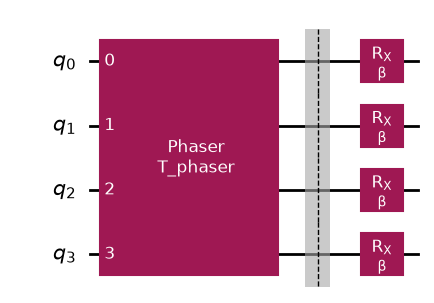

In [17]:
layer_picture = QuantumCircuit(4)
schematic_block(layer_picture, 'Phaser\nT_phaser', 'ph')
layer_picture.barrier()
layer_picture.rx(Parameter('β'), range(4))
draw_and_export(layer_picture, '02_QAOA_layer')

论文公式 (3) 的一层算符为

$$
U_l=e^{-i\beta_l H_M}e^{-i\gamma_l H_C}.
$$

矩阵右侧先作用，因此从左到右执行 $e^{-i\gamma_l H_C}$，再执行 $e^{-i\beta_l H_M}$。正向电路按 $l=1,\ldots,p$ 逐层加入这两段。

整段 phaser 的时间来自公式 (9)：

$$
T_{\mathrm{phaser}}
=\left(c+n_P+4\left\lceil\log_2 k\right\rceil\right)T_{\mathrm{LC}}.
\tag{9}
$$

整段 mixer 的时间来自公式 (8)：

$$
T_{\mathrm{mixer}}=n_P T_{\mathrm{LC}}.
\tag{8}
$$

对 $k=8$，$4\lceil\log_2 k\rceil=12$，因此

$$
T_{\mathrm{layer}}=(c+2n_P+12)T_{\mathrm{LC}},
\qquad T_U=pT_{\mathrm{layer}}.
$$

这里 $p$ 是 QAOA 层数；$n_P$ 是单比特相位门分解的逻辑周期数。Phaser 后辅助位复原为 $|0\rangle$，mixer 只操作数据位。

### 图 3：逆 QAOA


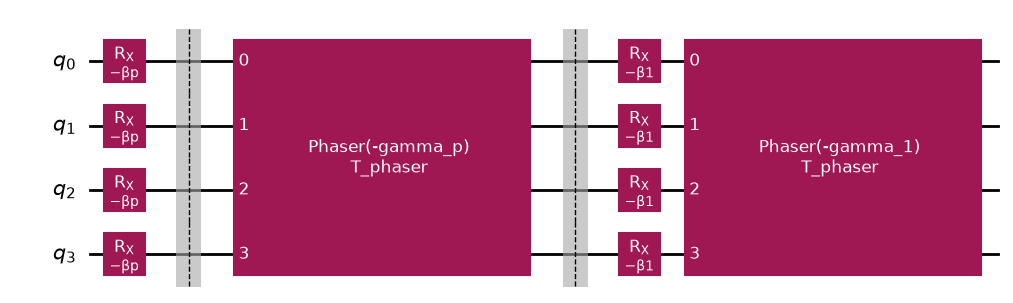

In [18]:
inverse_picture = QuantumCircuit(4)
inverse_picture.rx(-Parameter('βp'), range(4)); inverse_picture.barrier()
schematic_block(inverse_picture, 'Phaser(-gamma_p)\nT_phaser', 'phdg')
inverse_picture.barrier()
inverse_picture.rx(-Parameter('β1'), range(4))
schematic_block(inverse_picture, 'Phaser(-gamma_1)\nT_phaser', 'phdg')
draw_and_export(inverse_picture, '03_inverse_QAOA')

设 $P_l=e^{-i\gamma_l H_C}$、$M_l=e^{-i\beta_l H_M}$。正向单层的时间顺序是 $P_l\to M_l$；逆向单层是

$$
M_l^\dagger\to P_l^\dagger,
\qquad
M_l^\dagger=e^{+i\beta_l H_M},\quad
P_l^\dagger=e^{+i\gamma_l H_C}.
$$

按层来看，逆电路从 $p$ 层撤销到第 $1$ 层：

$$
\mathrm{Mixer}(-\beta_p)
\to\mathrm{Phaser}(-\gamma_p)
\to\cdots\to
\mathrm{Mixer}(-\beta_1)
\to\mathrm{Phaser}(-\gamma_1).
$$

代码中的 `.inverse()` 同时完成门的逆序与取逆。只改变角度符号却保留顺序，通常不会得到逆算符。图中省略了中间的逆向层。

论文模型给出

$$
T_{U^\dagger}=T_U
=p\left(T_{\mathrm{phaser}}+T_{\mathrm{mixer}}\right).
$$

每轮 AA 同时含 $U$ 和 $U^\dagger$，所以共有 $2p$ 个 phaser 和 $2p$ 个 mixer。

### 图 4：8-SAT 子句 Phaser


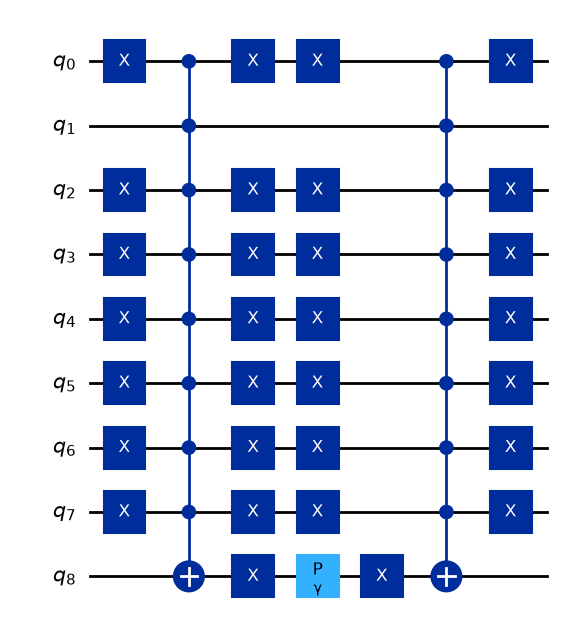

In [19]:
clause_picture = phaser(N_DEMO, [CLAUSES_DEMO[0]], Parameter('γ'))
draw_and_export(clause_picture, '04_8SAT_clause_phaser')

图示子句为

$$
C_j(x)=x_0\lor\neg x_1\lor x_2\lor\cdots\lor x_7.
$$

正文公式 (4)–(5) 用子句满足数定义 cost Hamiltonian：

$$
H_C=-\sum_{j=1}^{m}\sum_{x\in\{0,1\}^n}
C_j(x)|x\rangle\langle x|.
$$

因此 phaser 的目标相位是

$$
e^{-i\gamma_l H_C}|x\rangle
=\exp\!\left(i\gamma_l\sum_j C_j(x)\right)|x\rangle.
$$

用一个清零辅助位 $f$ 搭建单子句相位：

$$
|x\rangle|0\rangle_f
\xrightarrow{\mathrm{compute}}
|x\rangle|C_j(x)\rangle_f
\xrightarrow{P(\gamma_l)}
e^{i\gamma_l C_j(x)}|x\rangle|C_j(x)\rangle_f
\xrightarrow{\mathrm{uncompute}}
e^{i\gamma_l C_j(x)}|x\rangle|0\rangle_f.
$$

这里 $P(\gamma)=\operatorname{diag}(1,e^{i\gamma})$。正相位来自 $H_C$ 的负号。

代码先对正文字对应的数据位施加 $X$，让所有文字均为假的模式映射成全 $1$ 控制条件；MCX 得到 UNSAT 标记，再用 $X_f$ 转成 SAT 标记。恢复数据位并在施加相位后反计算，辅助位复原。

> [!note] 功能电路与论文编译
> MCX 图解释可逆功能。论文 Fig.2C、Sec.IV.C 和 Appendix B 用 CCZ 资源态、测量及反馈构建 TACU。$k=8$ 的单个相位 gadget 使用 $7$ 个 CCZ 态和 $52$ 个 $|0\rangle$ 辅助位，延迟为 $(n_P+12)T_{\mathrm{LC}}$。公式 (9) 给的是所有子句组成的完整 phaser，不能直接由图里的 MCX 深度替代。
> **[原文内部约定问题，p.4 与 p.10]** 式 (4) 的负号与式 (3) 推出正相位 $e^{+i\gamma C_j(x)}$，式 (20) 印刷为负相位 $e^{-i\gamma C_j(x)}$。本实现明确选式 (3)–(4) 的约定，即 `p(+gamma)`。

> **[功能等价简化]** 用 SAT 标记而非唯一 UNSAT 模式实现子句相位。等价关系是 $e^{i\gamma C_j}=e^{i\gamma}e^{-i\gamma(1-C_j)}$；对控制文字的 X 位置、相位号和全局相位必须一起核对，不能只比较两张图的 X 门位置。


### 图 5：Mixer 的相位实现


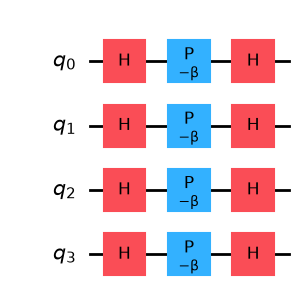

In [20]:
mixer_picture = QuantumCircuit(4)
beta = Parameter('β')
for wire in range(4):
    mixer_picture.h(wire); mixer_picture.p(-beta, wire); mixer_picture.h(wire)
draw_and_export(mixer_picture, '05_mixer_phase_basis')

论文采用

$$
H_M=\frac12\sum_{j=1}^{n}X_j,
\qquad
e^{-i\beta_l H_M}=\bigotimes_{j=1}^{n}R_x(\beta_l),
$$

其中

$$
R_x(\theta)=e^{-i\theta X/2}.
$$

因此 Qiskit 应使用 `rx(beta)`。X 基底相位实现为

$$
H P(-\beta_l)H=e^{-i\beta_l/2}R_x(\beta_l).
$$

对全部 $n$ 根线，差异是整体相位 $e^{-in\beta_l/2}$，不改变测量概率。

在足够资源态工厂供应的假设下，所有单比特相位分解并行执行：

$$
T_{\mathrm{mixer}}=n_P T_{\mathrm{LC}}.
$$

因此不用乘 $n$。$n_P$ 近似与相位合成的 T 门消耗数相关，但不能未经核对直接用 Table III 的 $N_T$ 列替换。

### 图 6：SAT Oracle


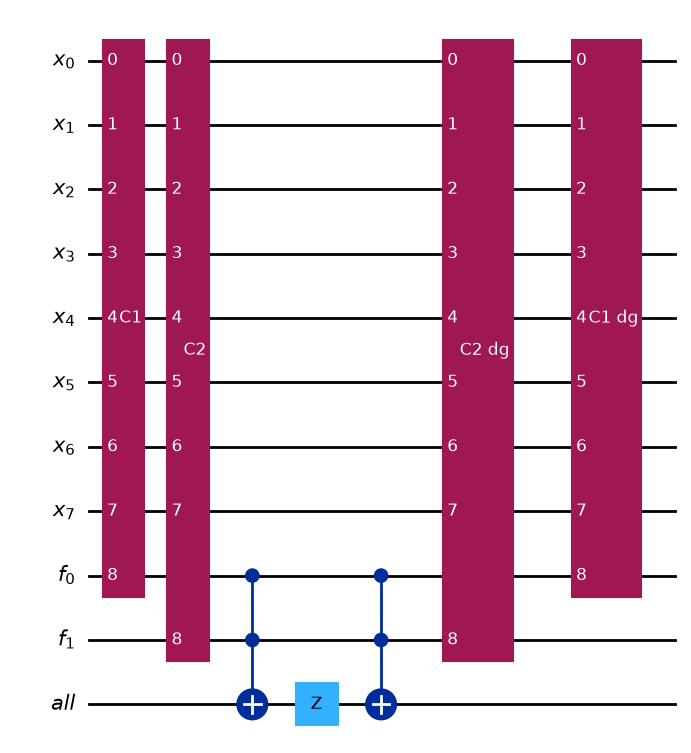

In [21]:
x_reg = QuantumRegister(8, 'x')
flag_reg = QuantumRegister(2, 'f')
all_reg = QuantumRegister(1, 'all')
oracle_picture = QuantumCircuit(x_reg, flag_reg, all_reg)
for j, clause in enumerate(CLAUSES_DEMO):
    oracle_picture.append(clause_compute(8, clause).to_gate(label=f'C{j+1}'), list(x_reg)+[flag_reg[j]])
oracle_picture.ccx(flag_reg[0], flag_reg[1], all_reg[0])
oracle_picture.z(all_reg[0])
oracle_picture.ccx(flag_reg[0], flag_reg[1], all_reg[0])
for j in reversed(range(2)):
    oracle_picture.append(clause_compute(8, CLAUSES_DEMO[j]).inverse().to_gate(label=f'C{j+1} dg'), list(x_reg)+[flag_reg[j]])
draw_and_export(oracle_picture, '06_SAT_oracle')

整份 SAT 公式的满足标记是

$$
C(x)=\bigwedge_{j=1}^{m}C_j(x),
\qquad
O_C|x\rangle=(-1)^{C(x)}|x\rangle.
$$

依次计算各条子句 OR，把标记经 AND 树汇总，对总标记施加 $Z$，然后反计算 AND 和所有子句。所有辅助位最终回到 $|0\rangle$。

图中 $m=2$，单个 Toffoli 就能汇总两个标记；Notebook 的紧凑版本直接对两个标记使用受控 $P(\pi)$，功能等价。

正文公式 (10) 给出整个 oracle 的近似时间：

$$
T_{O_C}=4c\log_2\!\left(\frac{km}{c}\right)T_{\mathrm{LC}}.
\tag{10}
$$

这一项已经含正算和反算，不再乘 $2$。Appendix C 的实现通过有意延迟与辅助位回收，使空间和资源态需求受 phaser 的预算约束。正文没有把公式 (10) 逐框分摊，所以图中不自行指定每个 compute/AND 框的微秒数。

### 图 7：全零态 Oracle


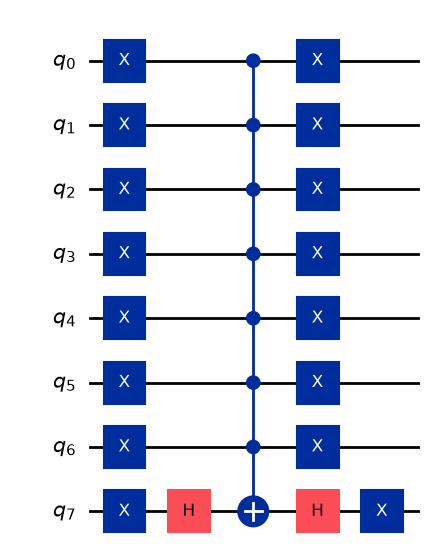

In [22]:
draw_and_export(zero_oracle(8), '07_zero_oracle')

全零态 oracle 的功能是

$$O_0=I-2|0^n\rangle\langle0^n|=X^{\otimes n}(I-2|1^n\rangle\langle1^n|)X^{\otimes n}.$$

它只将全零基态的振幅乘 -1，其余基态不变。代码先 X 全部数据位，再通过目标位 H–MCX–H 实现全 1 模式受控 Z，最后恢复 X。

> **[H 门位置说明]** 此处两个 H 仅作用在 MCX 的目标位上，用于实现受控 Z；不是此前移除的、夹在整个 O_0 模块前后的两组全寄存器 H。整体迭代直接调用 O_0。n=1 的实现使用 -Z，避免调用没有控制位的 MCX。

正文式 (11) 给出 $T_{O_0}=4\log_2(n)T_{\mathrm{LC}}$。这是原文 TACU 实现的近似预算，不是此 MCX 电路的准确整数深度；原文资源计数为最多 n-1 个 CCZ 态。


### 图 8：Phaser 流水线预算


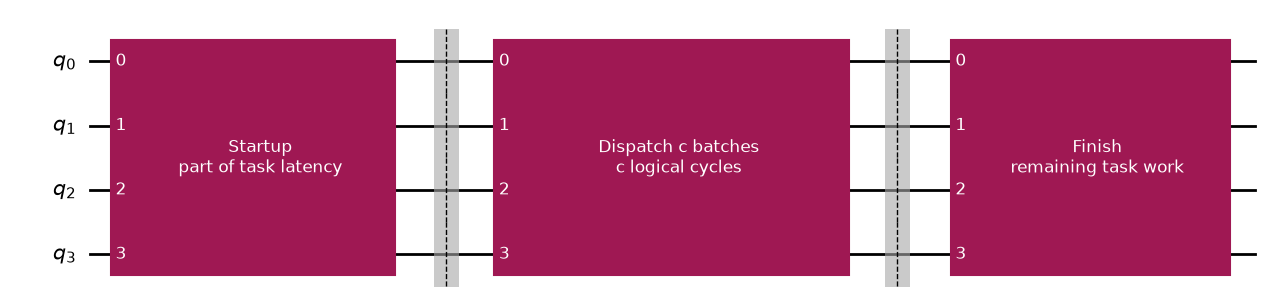

In [23]:
# Budget schematic: startup and finish share the nP+12 allowance.
schedule_picture = QuantumCircuit(4)
schematic_block(schedule_picture, 'Startup\npart of task latency', 'startup')
schedule_picture.barrier()
schematic_block(schedule_picture, 'Dispatch c batches\nc logical cycles', 'dispatch')
schedule_picture.barrier()
schematic_block(schedule_picture, 'Finish\nremaining task work', 'finish')
draw_and_export(schedule_picture, '08_phaser_timing_schedule')


染色在量子执行前产生 c 批，同批子句访问的数据位互不重叠。论文 TACU 每个任务只需一个逻辑周期访问原始数据位，之后可在各自辅助位上继续处理。因此可以每个逻辑周期派发一批，而不必等前一批全部完成；Pauli-Z 修正推迟到 phaser 末尾。

令 $L=\lceil\log_2k\rceil$。p.23 Appendix B 给出的单任务延迟预算为

$$\tau_{\mathrm{task}}=(3L+n_P+L)T_{\mathrm{LC}}=(n_P+4L)T_{\mathrm{LC}}.$$

三项分别为树形 AND 写入、单比特相位合成、逐层测量清除。p.11 Corollary IV.1 给出

$$\mathrm{LogicalDepth}(V_C)\le c+n_P+4L.$$

> **[更正旧说明]** 额外的 $n_P+4L$ 同时预算了首次派发前准备和末次派发后收尾，不是仅在全部派发后发生的等待。图中「Startup」与「Finish」合计使用该预算，未给两者各自编造周期数。

正文式 (9) 采用上述预算写作

$$T_{\mathrm{phaser}}=(c+n_P+4L)T_{\mathrm{LC}},\qquad k=8\Rightarrow L=3.$$

> **[与原文实现不同]** 代码中的普通 MCX phaser 没有实现这一流水线；c 也是手动提供，没有实际执行染色。图 8 仅解释论文的资源预算，不能作为所画功能电路的实测运行轨迹。


### 图 9：数值资源预算


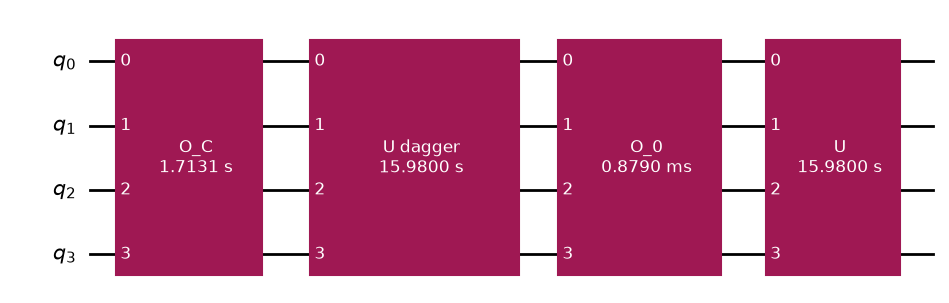

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [24]:
numeric_picture = QuantumCircuit(4)
numeric_labels = [
    ('OC', f"O_C\n{timing['component_seconds']['OC']:.4f} s"),
    ('Udg', f"U dagger\n{timing['T_U_seconds']:.4f} s"),
    ('O0', f"O_0\n{timing['component_seconds']['O0']*1000:.4f} ms"),
    ('U', f"U\n{timing['T_U_seconds']:.4f} s"),
]
for name, label in numeric_labels:
    schematic_block(numeric_picture, label, name)
draw_and_export(numeric_picture, '09_numerical_timing')
display(Math(fr"n={timing['n']},\quad m={timing['m']},\quad p={timing['p']},\quad c={timing['c']},\quad n_P={timing['nP']},\quad d={timing['d']}"))
display(Math(fr"T_{{\mathrm{{mixer}}}}={timing['component_seconds']['mixer']*1000:.6f}\,\mathrm{{ms}},\quad T_{{\mathrm{{phaser}}}}={timing['component_seconds']['phaser']*1000:.6f}\,\mathrm{{ms}}"))
display(Math(fr"T_Q={timing['T_AA_round_seconds']:.6f}\,\mathrm{{s}},\quad T_q={timing['T_eq7_seconds']/3600:.4f}\,\mathrm{{h}}"))

数值输入来自第 9 节 RESOURCE_INPUTS，当前输出会随参数重新计算。

$$T_{\mathrm{LC}}=d\times1\,\mu\mathrm{s},\quad T_U=p(T_{\mathrm{phaser}}+T_{\mathrm{mixer}}),\quad T_Q=2T_U+T_{O_C}+T_{O_0}.$$

$$P_{\mathrm{model}}=2^{-0.69p^{-0.32}n},\quad R_{\mathrm{Eq7}}\simeq\frac{\pi}{4\sqrt{P_{\mathrm{model}}}},\quad T_{\mathrm{Eq7}}=R_{\mathrm{Eq7}}T_Q.$$

只额外计一次初始演化的组件预算为 $T_U+T_{\mathrm{Eq7}}$；正文稳健协议预算约为 $4T_{\mathrm{Eq7}}$。后者不是在此小例子中执行了四次迭代。

> **[资源估算假设]** 默认 n=191,p=253,d=29 与 Table III cubic 行相同，但 c=2112 是经验值，nP=27 是演示输入；表中的 N_T=24 不能在未核对编译方法时直接替代 nP。因此没有复现 64.57 h 交叉点。模型成功率不是小例子的成功率，模型时间也不是对字面式 (6) 电路的成功保证。

初始 H、重置、测量、经典验证、训练与布线没有单独数值；c 未经实际染色计算。式 (10)–(11) 是正文近似，而非附录中的完整整数调度。


## 11. 导出同一份正文、资源模型和检查结果

先保存 Notebook，再运行本格。导出从已保存 Notebook 中读取九段图下正文及原文对照，不再维护另一份嵌入说明。数值结果根据当前参数补充；图与笔记一起放入 Obsidian vault。


In [25]:
# Saved Notebook markdown is the single source of the reading captions.
# Save edits before running this cell; no external Markdown/Python is imported.
def export_obsidian_note(timing):
    saved = json.loads(NOTEBOOK_PATH.read_text(encoding='utf-8'))
    sections = []
    for cell in saved['cells']:
        section = cell.get('metadata', {}).get('obsidian_section')
        if section:
            sections.append((section, ''.join(cell['source'])))
    if len(sections) != 9:
        raise ValueError('Save the Notebook with all nine caption sections before exporting.')
    audits = [''.join(cell['source']) for cell in saved['cells']
              if cell.get('metadata', {}).get('paper_audit')]
    if len(audits) != 1:
        raise ValueError('The saved paper audit section is missing or duplicated.')
    header = '---\ntitle: QAOA 电路与原文对照\ntags: [QAOA, 论文复现, 电路, 资源估算]\npaper: arXiv:2504.01897v1\n---\n\n# QAOA 电路、时间预算与原文对照\n\n'
    pieces = [header, '本笔记由已保存 Notebook 的图下正文生成。功能电路按式 (6) 字面执行；原文约定问题和实现差异在各节及末尾标明。\n']
    for i, (section, caption) in enumerate(sections, 1):
        pieces.append(f"\n## {i}. {section['title']}\n\n![[obsidian_assets/{section['stem']}.png|1100]]\n\n{caption.strip()}\n")
    t = timing['component_seconds']
    pieces.append(rf"""
### 本次模型计算结果

$$n={timing['n']},\quad m={timing['m']},\quad p={timing['p']},\quad c={timing['c']},\quad n_P={timing['nP']},\quad d={timing['d']}.$$

$$T_{{\mathrm{{mixer}}}}={t['mixer']*1000:.6f}\,\mathrm{{ms}},\quad T_{{\mathrm{{phaser}}}}={t['phaser']*1000:.6f}\,\mathrm{{ms}}.$$

$$T_{{O_C}}={t['OC']:.6f}\,\mathrm{{s}},\quad T_{{O_0}}={t['O0']*1000:.6f}\,\mathrm{{ms}}.$$

$$T_U={timing['T_U_seconds']:.6f}\,\mathrm{{s}},\quad T_Q={timing['T_AA_round_seconds']:.6f}\,\mathrm{{s}}.$$

模型成功率：{timing['success_model']:.6g}；连续轮数预算：{timing['R_eq7_continuous']:.3f}。

式 (7) 预算：{timing['T_eq7_seconds']/3600:.4f} h；加一次初始 U：{timing['T_with_initial_U_seconds']/3600:.4f} h；正文稳健协议预算：{timing['T_robust_main_text_approx_seconds']/3600:.4f} h。
""")
    pieces.extend(['\n'+audits[0], '\n## 文件使用\n\n将本笔记与同目录 obsidian_assets 文件夹一起复制到 vault。Notebook 的重新生成文件写入 results/；notes/ 保存用于阅读的正式笔记。原始参考文件 sources/ 不修改。\n'])
    note_path = OUTPUT_DIR / 'AA_QAOA_电路与时间估算_Obsidian.md'
    note_path.write_text('\n'.join(pieces), encoding='utf-8')
    return note_path

note_path = export_obsidian_note(timing)
(DATA_DIR / 'time_estimates.json').write_text(json.dumps(timing, ensure_ascii=False, indent=2), encoding='utf-8')
(DATA_DIR / 'verification.json').write_text(json.dumps(verification, ensure_ascii=False, indent=2), encoding='utf-8')
with (DATA_DIR / 'time_estimates.csv').open('w', newline='', encoding='utf-8-sig') as stream:
    writer = csv.writer(stream)
    writer.writerow(['component', 'paper_equation', 'modeled_logical_cycles_per_call', 'modeled_seconds_per_call', 'calls_per_round', 'modeled_seconds_per_round'])
    for component, equation, count in [('mixer',8,2*timing['p']),('phaser',9,2*timing['p']),('OC',10,1),('O0',11,1)]:
        writer.writerow([component,equation,timing['component_logical_cycles'][component],timing['component_seconds'][component],count,count*timing['component_seconds'][component]])
print('已导出与已保存 Notebook 正文一致的 Obsidian 笔记:', note_path.name)
print('理想电路检查:', verification['status'], '；未验证容错调度或论文完整交叉点。')


已导出与已保存 Notebook 正文一致的 Obsidian 笔记: AA_QAOA_电路与时间估算_Obsidian.md
理想电路检查: PASS ；未验证容错调度或论文完整交叉点。


## 原文对照：当前实现的约定、差异和未实现部分

以下以项目保存的 arXiv:2504.01897v1 PDF 为准，页码为印刷页码。差异分为「原文内部约定问题」「功能等价简化」「资源估算假设」；不将推断写成作者的明确说明。

1. **[原文内部约定问题：初态与式 (6)]** p.3 式 (2)–(3) 定义 $|\psi\rangle=U|+\rangle^{\otimes n}$，且 $U$ 只含演化；p.4 式 (6) 使用 $UO_0U^\dagger O_C$，并将 $O_0$ 定义为全零态翻相。当前代码按式 (6) 字面执行，不在 $O_0$ 前后补全寄存器 H。由定义推得 $UO_0U^\dagger$ 针对 $U|0^n\rangle$，与式 (2) 的初态一般不同。原文未在此明确说明是否改用了完整制备器的约定，因此不能仅据字面电路宣称标准 AA 的成功概率规律成立。
2. **[原文内部约定问题：相位正负号]** p.4 式 (4) 的 $H_C=-\sum_jC_j$ 与式 (3) 给出 $e^{+i\gamma\sum_j C_j(x)}$；p.10 式 (20) 却打印 $e^{-i\gamma C_j(x)}$。当前代码遵循式 (3)–(4)，对 SAT 标记施加 `p(+gamma)`，不是逐字照抄式 (20)。如果使用另一套角度符号约定，必须同时转换参数，不能仅换一个符号。
3. **[功能等价简化：相位 gadget]** `phaser()` 使用理想 MCX、精确 `p()` 和普通反计算；原文 Fig.2C、Sec.IV.C、Appendix B 使用 CCZ 资源态、Pauli 测量和反馈构建 TACU。当前代码没有实现 TACU，也没有将任意角度门分解为 Clifford+T。功能门图的深度不是式 (9) 的容错逻辑周期数。
4. **[功能等价简化：Oracle]** `sat_oracle()` 直接给全真子句标记施加受控相位，与 compute–AND–Z–uncompute 在清零辅助位的输入上功能相同；它不是 Appendix C 的有意延迟、回收辅助位和资源态调度实现。`zero_oracle()` 的目标位 H–MCX–H 用于实现受控 Z，是 oracle 内部的门，与已移除的两组全寄存器 H 不同。
5. **[更正旧说明：流水线]** p.11 Corollary IV.1 给出深度上界 $c+n_P+4\lceil\log_2k\rceil$。其中额外项覆盖首次派发前准备和末次派发后收尾；不是说派发结束后必定再等完整的 $n_P+4\lceil\log_2k\rceil$。p.23 Appendix B 将单个任务延迟分为 AND 写入 $3L$、单比特相位 $n_P$、测量清除 $L$，$L=\lceil\log_2k\rceil$。图 8 是预算示意，不是串行执行轨迹。
6. **[资源估算假设：颜色与相位成本]** `c` 和 `nP` 都是手动输入，代码未生成随机大实例、冲突图或实际染色。默认 $c=2112\approx12r$ 来自经验选取；$n_P=27$ 是演示值。Table III 的 cubic 行为 $n=191,p=253,d=29,N_T=24$；$N_T$ 是 T 门数量，不自动等于任意实现中的 $n_P$。当前输入不构成该表的完整重现。
7. **[资源估算假设：成功率与总时间]** 式 (7) 使用的 $P=2^{-0.69p^{-0.32}n}$ 是所引用研究给出的随机 8-SAT 实例平均模型；它不是小例子的测量成功率。`T_eq7_seconds` 是原文预算模型，不是对字面式 (6) 仿真成功率的保证。式 (10)–(11) 是正文近似，未实施附录中完整的取整、调度与空间约束。
8. **[资源估算假设：稳健协议与未计开销]** p.9 设置 $\delta=1/2^4=1/16$，对应约 4 倍协议预算。代码报告 $4T_q$，未实现 Theorem IV.1 的逐阶段尝试、失败后重新制备及测量停止条件。初始 H、重置、读出、经典验证、训练和布线开销未单列；资源态工厂、物理噪声和译码器未模拟。
9. **[实例与输入边界]** 演示是固定 $n=8,m=2,p=2,R=1$，不是 $m/n=176$ 的随机阈值实例。原文 Sec.IV.F 允许有放回变量抽样；代码对重复文字、恒真子句作精确布尔化简，避免 MCX 重复控制位。空 OR 为假；空整份公式不在本代码支持范围内。`x_i` 对应整数赋值的第 i 位，Qiskit ket 字符串按 $|x_{n-1}\cdots x_0\rangle$ 显示。

**验证范围。** PASS 表示理想功能电路与独立数学参考一致，包括相位符号、辅助位清零、逆电路和多轮式 (6) 的演化；不表示复现了完整容错编译、论文交叉点或标准 AA 成功率定理。

[原文 v1](https://arxiv.org/abs/2504.01897v1)
